In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

In [20]:
df = pd.read_csv('TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_204435.csv')
sim_f0_kin_res = np.array([5.566,4.680,4.645,4.434,4.162,6.206])
theo_f0_kin_res = np.array([8.51077059,7.49291156,8.20177958,
                            7.14371248,7.8479671,8.8257005])

In [21]:
#Invert Selection to be compatabile
inverted = -(df['Magnitude (dB)'])

#Find the peaks of the data in 100MHz range
peaks,_ = find_peaks(inverted,height=55,distance=135)

#Remove Peaks based on inspection
remove = [0,1,3,4,5,7,17,19,20,21,22,24,25,26,28,29,32]
peaks = np.delete(peaks,remove)


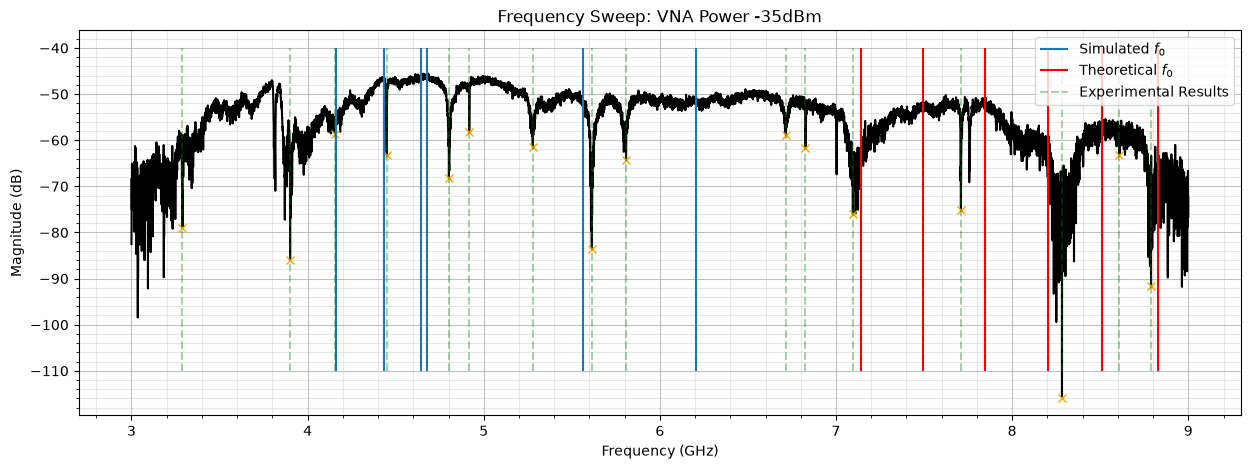

In [22]:
plt.figure(figsize=(15,5))
plt.title('Frequency Sweep: VNA Power -35dBm')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequency (GHz)')
plt.plot(df['Frequency (GHz)'],
         df['Magnitude (dB)'],
         c='black',ls='-')
plt.plot(df['Frequency (GHz)'][peaks],
         df['Magnitude (dB)'][peaks],
         'x',color='orange')

plt.vlines(sim_f0_kin_res,ymin=-110,ymax=-40,label=r'Simulated $f_0$')
plt.vlines(theo_f0_kin_res,ymin=-110,ymax=-40,colors='r',label=r'Theoretical $f_0$')
plt.vlines(df['Frequency (GHz)'][peaks],
           ymin=-110,ymax=-40,colors='green',ls='--',alpha=0.35,label='Experimental Results')

plt.grid(which='major',alpha=0.8)
plt.grid(which='minor',alpha=0.3)
plt.legend(loc='best')
plt.minorticks_on()
plt.show()


In [23]:
print(df['Frequency (GHz)'][peaks])
csv = df['Frequency (GHz)'][peaks]
csv.to_csv('out.csv',index=True)

386     3.28950
1201    3.90075
1542    4.15650
1932    4.44900
2403    4.80225
2557    4.91775
3038    5.27850
3485    5.61375
3744    5.80800
4954    6.71550
5102    6.82650
5461    7.09575
6279    7.70925
7044    8.28300
7479    8.60925
7718    8.78850
Name: Frequency (GHz), dtype: float64


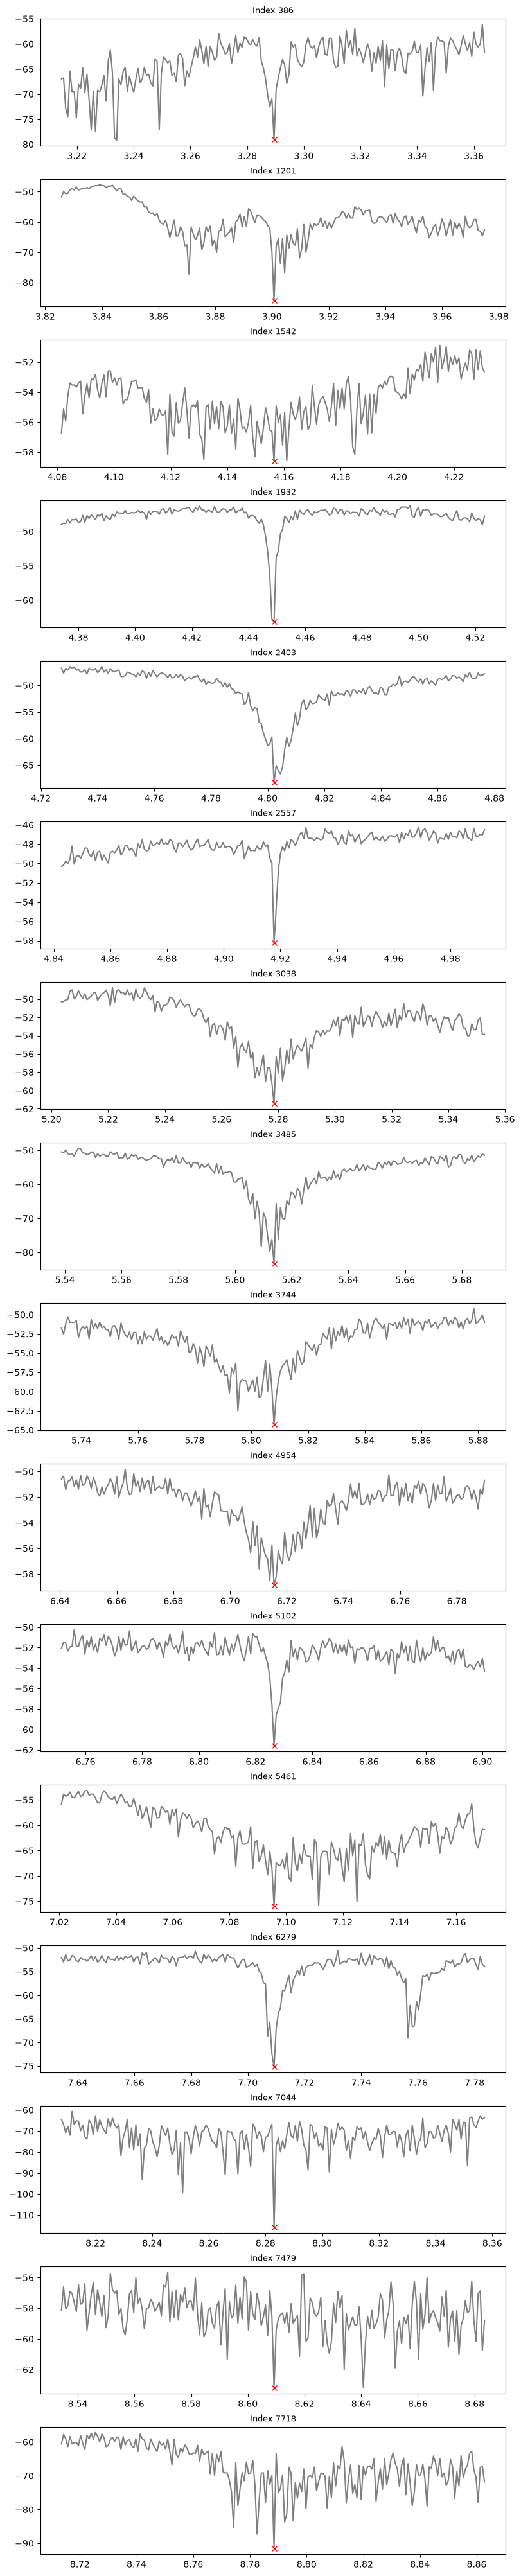

In [24]:
window = 100  # points either side of the peak

n = len(peaks)  # your 28 indices

#Define Plots
fig, axs = plt.subplots(n, 1, figsize=(8, 2.5 * n), layout='constrained', squeeze=False)
axs = axs.flatten()

#Simplfy
freq = df['Frequency (GHz)']
mag = df['Magnitude (dB)']

#Loop over all peaks and plot figures
for ax, idx in zip(axs, peaks):
    #Frequency Bounds of plot
    lo = max(idx - window, 0)        #Protects from negative index
    hi = min(idx + window, len(df))  #Protects from out of bound indexs

    #Plot data from Ranges
    ax.plot(freq.iloc[lo:hi], mag.iloc[lo:hi], c='black', ls='-', alpha=0.5)
    ax.plot(freq.iloc[idx], mag.iloc[idx], 'x', color='red')

    #Label Figures
    ax.set_title(f'Index {idx}', fontsize=9)

plt.show()